<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import kagglehub
import pandas as pd


In [9]:
path=kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")
print(path)

Using Colab cache for faster access to the 'salary-dataset-simple-linear-regression' dataset.
/kaggle/input/salary-dataset-simple-linear-regression


In [10]:
import os
os.listdir(path)

['Salary_dataset.csv']

In [12]:
df=pd.read_csv(path+"/Salary_dataset.csv")

In [13]:
df.sample(5)

,Unnamed: 0,YearsExperience,Salary
27,27,9.7,112636.0
1,1,1.4,46206.0
7,7,3.3,54446.0
22,22,8.0,101303.0
16,16,5.2,66030.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [16]:
df.shape

(30, 3)

In [17]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [18]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

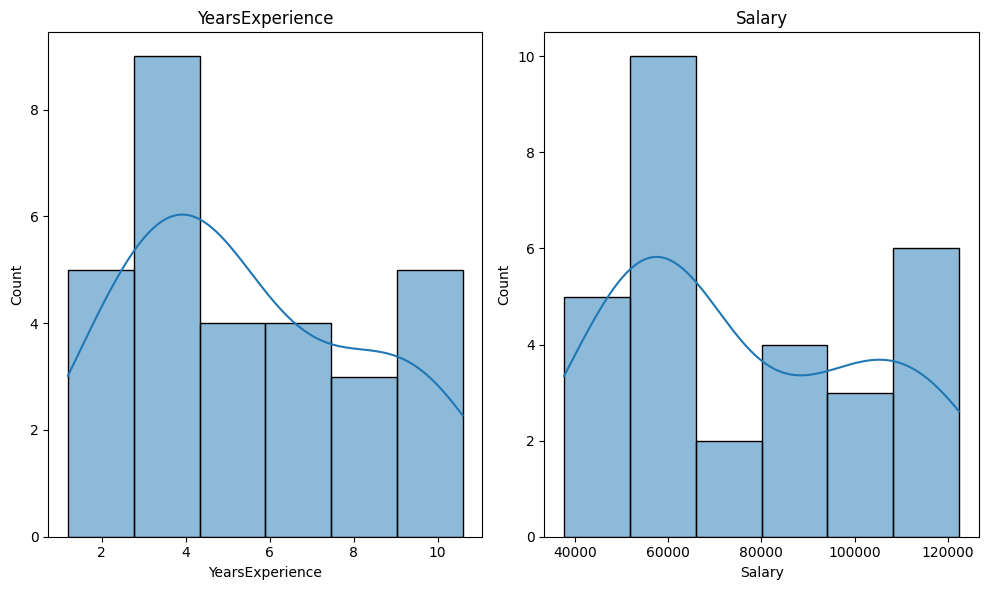

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.histplot(df["YearsExperience"], kde=True)
plt.title("YearsExperience")


plt.subplot(1,2,2)
sns.histplot(df["Salary"], kde=True)
plt.title("Salary")

plt.tight_layout()
plt.show()

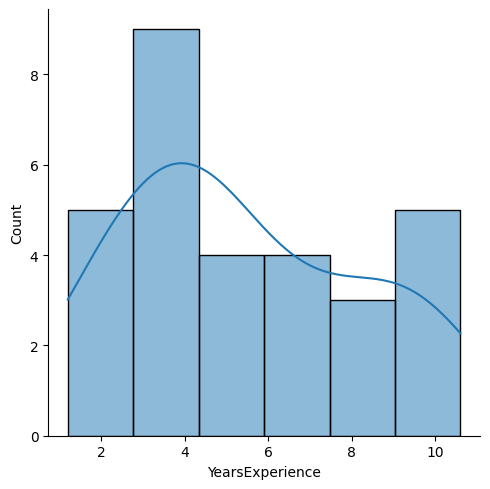

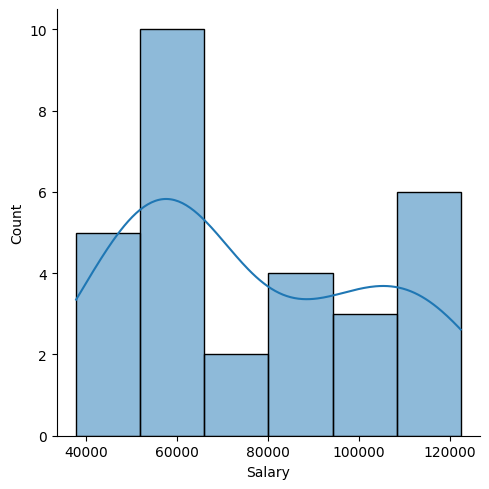

In [29]:
sns.displot(df["YearsExperience"], kde=True)
sns.displot(df["Salary"], kde=True)

<Axes: xlabel='YearsExperience', ylabel='Salary'>

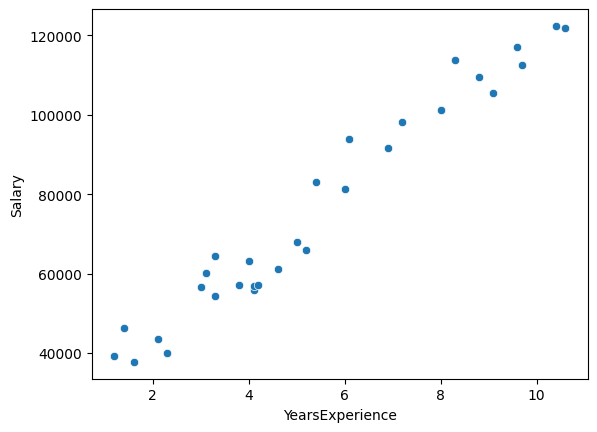

In [30]:
sns.scatterplot(x="YearsExperience", y="Salary", data=df)

In [31]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler


In [35]:
scale=MinMaxScaler()
scale.fit(df)
df=pd.DataFrame(scale.transform(df),columns=df.columns)

In [37]:
x_train,x_test,y_train,y_test=train_test_split(df.drop("Salary",axis=1),df["Salary"],test_size=0.2,random_state=42)


In [55]:
lr=LinearRegression()
lr.fit(x_train,y_train)
lr.coef_

array([1.0463485])

In [56]:
lr.intercept_

np.float64(-0.02413442160275353)

In [41]:
y_pred=lr.predict(x_test)

In [44]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.07425530156812828
MSE: 0.006952407238200631
RMSE: 0.08338109640800265
R2 Score: 0.9024461774180499


In [51]:
class MeraLR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, x_train, y_train):

        num = 0
        den = 0

        # Assuming x_train is a DataFrame with a single feature column
        # Extract the single feature column from x_train as a Series for easier handling.
        x_feature = x_train.iloc[:, 0] # Get the first (and only) column as a Series

        x_mean = x_feature.mean()
        y_mean = y_train.mean()

        for i in range(len(x_train)): # Iterate through integer positions
            x_val = x_feature.iloc[i] # Access by integer position
            y_val = y_train.iloc[i]   # Access by integer position

            num = num + ((x_val - x_mean) * (y_val - y_mean))
            den = den + ((x_val - x_mean) * (x_val - x_mean))

        self.m = num / den
        self.b = y_mean - (self.m * x_mean)
        print(f"Calculated slope (m): {self.m}")
        print(f"Calculated intercept (b): {self.b}")

    def predict(self, x_test):
        # x_test will be a DataFrame (like x_train).
        # The operation `self.m * x_test + self.b` will perform element-wise
        # multiplication and broadcasting correctly with pandas DataFrames/Series.
        print(f"Predicting for input:\n{x_test}")
        return self.m * x_test + self.b

In [52]:
sc=MeraLR()

In [53]:
sc.fit(x_train,y_train)

Calculated slope (m): 1.0463485003129125
Calculated intercept (b): -0.02413442160275353
